In [76]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator
from scipy.io import loadmat
import matplotlib.pyplot as plt
from skimage.transform import iradon
from tqdm import tqdm
from joblib import Parallel, delayed
import time
import cv2
import math

constants

In [77]:
figures_path = "/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/cw/figures/"
show_all_slices = False
compute_all_slices = False
compute_axial_reconstruction = False
compute_helical_sinograms = True

utility functions

In [78]:
def show_gray_img(img):
    plt.figure()
    plt.imshow(img, cmap='gray', origin='lower')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

def rotate(img, angle, crop=True):
    (h,w)=img.shape[:2]
    angle_rad=np.deg2rad(angle)
    center=(w//2,h//2)
    rotation_matrix=cv2.getRotationMatrix2D(center,angle,1.0)
    if not crop:
        new_w=int(abs(w*np.cos(angle_rad))+abs(h*np.sin(angle_rad)))
        new_h=int(abs(w*np.sin(angle_rad))+abs(h*np.cos(angle_rad)))
        rotation_matrix[0,2]+=(new_w-w)/2
        rotation_matrix[1,2]+=(new_h-h)/2
    else:
        new_w = w
        new_h = h
    return cv2.warpAffine(img,rotation_matrix,(new_w, new_h))

def interpolate(arr, i):
    if i < 0 or i > len(arr) - 1:
        raise Exception(f"Index {i} out of bounds for array size {len(arr)}")
    a = math.floor(i)
    b = math.ceil(i)
    if a == b and int(a) == a:
        return arr[int(a)]
    assert b == a + 1, f"{b} != {a} + 1"
    return abs(i - a) * arr[a] + abs(b - i) * arr[b]

load CT projection dataset

In [79]:
ct_projections_path = '/Users/piotrblaszyk/Documents/university/MRIGI/med-surg-imaging-70003/tutorials/msi-2-tutorial-m/CT projections.mat'
mat_data = loadmat(ct_projections_path)
axial_sinograms = mat_data['projections']
print("Axial dataset shape:", axial_sinograms.shape)
n_slices, n_detectors, n_angles = axial_sinograms.shape

Axial dataset shape: (190, 380, 180)


reconstruct

In [80]:
if compute_axial_reconstruction:
    axial_reconstructions = np.zeros((n_slices, n_detectors, n_detectors))
    for i in tqdm(range(n_slices)):
        theta = np.linspace(0, n_angles, n_angles, endpoint=False)
        axial_reconstructions[i] = iradon(axial_sinograms[i, :, :], theta=theta, filter_name="hann", circle=True)

print(axial_reconstructions.shape)

(190, 380, 380)


-0.0012414015991504873 0.03451338003285026


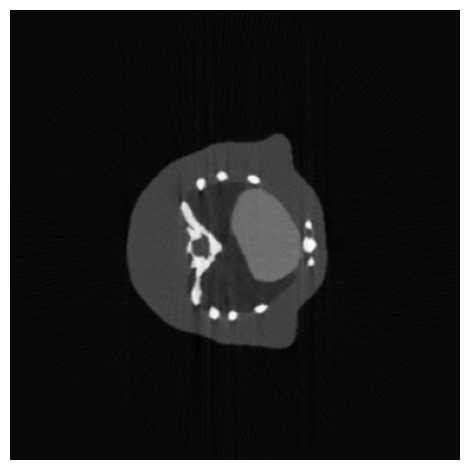

In [81]:
img = axial_reconstructions[109]
print(np.min(img), np.max(img))
show_gray_img(img)

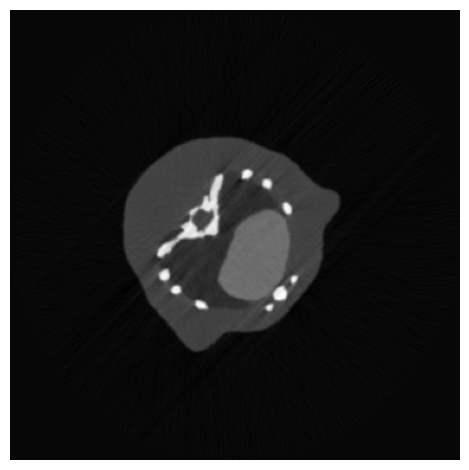

In [82]:
show_gray_img(rotate(img, angle=45))

compute helical sinograms (mine)

In [84]:
if compute_helical_sinograms:
    num_rotations = 19
    detector_width = 380
    detector_length = 10
    num_projections_per_rotation = 10
    res = np.zeros((    
        num_rotations,
        num_projections_per_rotation,
        detector_length,
        detector_width,
    ))
    for i in tqdm(range(num_rotations)):
        for j in range(num_projections_per_rotation):
            z_start = detector_length * (i + j / num_projections_per_rotation)
            rot_angle = (180 * (j / num_projections_per_rotation)) % 180
            for k in range(detector_length):
                z = z_start + k
                if z < axial_reconstructions.shape[0]:
                    slice_reconstructed = interpolate(axial_reconstructions, z)
                    slice_reconstructed_rotated = rotate(slice_reconstructed, rot_angle)
                    projection_1d = np.mean(slice_reconstructed_rotated, axis=0)
                    res[i, j, k] = projection_1d

print(res.shape)

100%|██████████| 19/19 [00:02<00:00,  8.23it/s]

(19, 10, 10, 380)


In [45]:
raise Exception()

Exception: 

compute helical sinograms (ChatGPT)

In [ ]:
# Define parameters
slice_thickness = 10      # Table movement / total slices
pitch = 1.0                     # Helical pitch

# Define axial Z positions
z_axial = np.arange(0, n_slices * slice_thickness, slice_thickness)

# Define helical Z positions
z_helical = np.linspace(0, z_axial[-1], n_slices)  # Adjust for helical spacing

# Create the interpolation function
interp_func = RegularGridInterpolator(
    (z_axial, np.arange(n_detectors), np.arange(n_angles)),  # Axial grid
    axial_sinograms,                                # Axial sinograms
    bounds_error=False,                        # Allow extrapolation outside bounds
    fill_value=0                               # Fill missing values with 0
)

# Create mesh grids for the projection dimensions
x_proj = np.arange(n_detectors)  # Projection coordinate
y_proj = np.arange(n_angles)  # Projection angle
xx, yy = np.meshgrid(x_proj, y_proj, indexing='ij')  # Create 2D grid

# Initialize helical dataset
helical_sinograms = np.zeros_like(axial_sinograms)

# Loop through helical Z positions and interpolate
for i, z in enumerate(z_helical):
    # Prepare points for interpolation (flatten the mesh grid)
    points = np.array([z * np.ones(xx.size), xx.ravel(), yy.ravel()]).T  # Shape: (N, 3)

    # Interpolate and reshape back to (n_detectors, n_angles)
    helical_sinograms[i, :, :] = interp_func(points).reshape(n_detectors, n_angles)

# Output the shape of the helical dataset
print("Helical dataset shape:", helical_sinograms.shape)

Helical dataset shape: (190, 380, 180)


compare 110th sinogram and reconstruction for axial and helical acquisition

In [28]:
sinograms = [
    axial_sinograms,
    helical_sinograms
]
names = [
    'axial',
    'helical'
]

In [ ]:
sinograms = []
reconstructions = []
for i in range(len(sinograms)):
    this = sinograms[i]
    sinogram = this[109, :, :]
    sinograms.append(sinogram)

    theta = np.linspace(0., 180., sinogram.shape[1], endpoint=False)
    reconstruction = iradon(sinogram, theta=theta, filter_name="hann", circle=True)
    reconstructions.append(reconstruction)

sinogram_diff = abs(sinograms[1] - sinograms[0])
reconstruction_diff = abs(reconstructions[1] - reconstructions[0])
diffs = [
    sinogram_diff,
    reconstruction_diff
]

data_diff = abs(sinograms[1] - sinograms[0])
print(len(data_diff.ravel()), np.count_nonzero(data_diff))

12996000 0


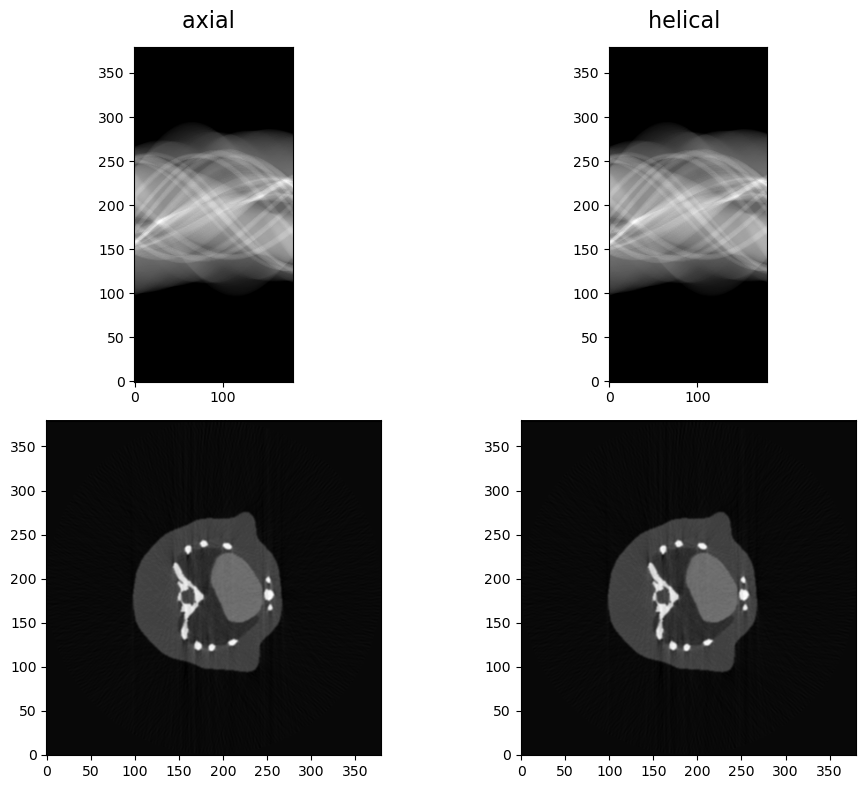

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(sinograms[0], cmap='gray', origin='lower')
axs[0, 1].imshow(sinograms[1], cmap='gray', origin='lower')
axs[1, 0].imshow(reconstructions[0], cmap='gray', origin='lower')
axs[1, 1].imshow(reconstructions[1], cmap='gray', origin='lower')
fig.suptitle(f'{(" " * 58).join(names)}', fontsize=16)
plt.tight_layout()
plt.show()
plt.close()

68400 0


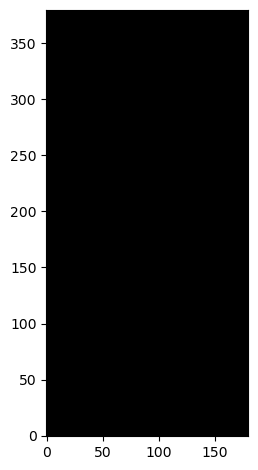

144400 0


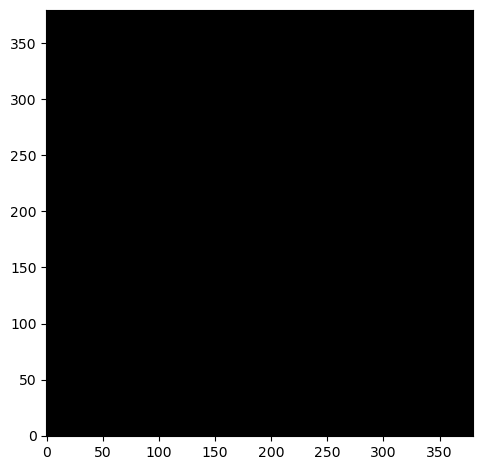

In [31]:
for diff in diffs:
    print(len(diff.ravel()), np.count_nonzero(diff))
    plt.imshow(diff, cmap='gray', origin='lower')
    plt.tight_layout()
    plt.show()
    plt.close()

reconstruct all slices

In [32]:
def task(i, j, show=False):
    slice = sinograms[i][j, :, :]
    theta = np.linspace(0., 180., slice.shape[1], endpoint=False)
    reconstruction_fbp = iradon(slice, theta=theta, filter_name="hann", circle=True)
    fig = plt.figure()
    plt.imshow(reconstruction_fbp, cmap='gray', origin='lower')
    if show:
        plt.show()
    fig.savefig(f"{figures_path}slice-{names[i]}-{j}.png", dpi=300, bbox_inches='tight')
    plt.close()

In [33]:
if compute_all_slices:
    start = time.time()
    for i in range(len(sinograms)):
        Parallel(n_jobs=8)(delayed(task)(i, j, show_all_slices) for j in range(0, 190, 1))
    end = time.time()
    print(f"Execution time: {end - start:.0f} seconds")